# Lab 2: Table Operations

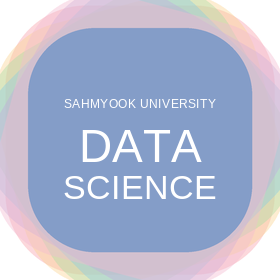

Welcome to Lab 2!  This week, we'll learn how to import a module and practice table operations. The [Python Reference](https://www.data8.org/sp26/reference/) has information that will be useful for this lab.

**Recommended Reading**:
 * [Introduction to Tables](https://www.inferentialthinking.com/chapters/03/4/Introduction_to_Tables)

**Submission**: When you're finished, run every cell and check that the tests pass, then download the notebook with **File → Download → Download .ipynb** and upload it to the LMS.

Let's begin by setting up the tests and imports by running the cell below.

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/lab/lab02')
os.makedirs('tests', exist_ok=True)
with open('lab02.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('lab02.ipynb')
print('Ready! (10 tests loaded)')

In [ ]:
# Don't change this cell; just run it.
import numpy as np
from datascience import *

# No need to worry about what this code means
from IPython.display import Javascript, display
display(Javascript(r"""
(() => {
  function pathLooksLikeTyping(e) {
    const path = e.composedPath ? e.composedPath() : [];
    for (const n of path) {
      if (!n) continue;
      if (n.tagName === 'INPUT' || n.tagName === 'TEXTAREA') return true;
      if (n.isContentEditable) return true;
      const role = n.getAttribute?.('role');
      if (role === 'textbox' || role === 'combobox' || role === 'searchbox') return true;
      const ariaMulti = n.getAttribute?.('aria-multiline');
      if (ariaMulti === 'true') return true;
      const cls = (n.className || "").toString().toLowerCase();
    }
    return false;
  }
  function handler(e) {
    if (e.key !== 'o' && e.key !== 'O') return;
    if (pathLooksLikeTyping(e)) {
      e.stopPropagation();
      if (e.stopImmediatePropagation) e.stopImmediatePropagation();
      if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
      return;
    }
    e.preventDefault();
    e.stopPropagation();
    if (e.stopImmediatePropagation) e.stopImmediatePropagation();
    if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
  }
  window.addEventListener('keydown', handler, true);
  window.addEventListener('keypress', handler, true);
  console.log("Installed: 'o' won't toggle output; 'o' should type inside any textbox-like UI (including JupyTutor).");
})();
"""))

## 1. Review: The Building Blocks of Python Code

The two building blocks of Python code are *expressions* and *statements*.  An **expression** is a piece of code that

* is self-contained, meaning it would make sense to write it on a line by itself, and
* usually evaluates to a value.

Here are two expressions that both evaluate to 3:

    3
    5 - 2
    
One important type of expression is the **call expression**. A call expression begins with the name of a function and is followed by the argument(s) of that function in parentheses. The function returns some value, based on its arguments. Some important mathematical functions are listed below.

| Function | Description                                                   |
|----------|---------------------------------------------------------------|
| `abs`      | Returns the absolute value of its argument                    |
| `max`      | Returns the maximum of all its arguments                      |
| `min`      | Returns the minimum of all its arguments                      |
| `pow`      | Raises its first argument to the power of its second argument |
| `round`    | Rounds its argument to the nearest integer                     |

Here are two call expressions that both evaluate to 3:

    abs(2 - 5)
    max(round(2.8), min(pow(2, 10), -1 * pow(2, 10)))

The expression `2 - 5` and the two call expressions given above are examples of **compound expressions**, meaning that they are actually combinations of several smaller expressions.  `2 - 5` combines the expressions `2` and `5` by subtraction.  In this case, `2` and `5` are called **subexpressions** because they're expressions that are part of a larger expression.

A **statement** is a whole line of code.  Some statements are just expressions.  The expressions listed above are examples.

Other statements *make something happen* rather than *having a value*. For example, an **assignment statement** assigns a value to a name.

A good way to think about this is that we're **evaluating the right-hand side** of the equals sign and **assigning it to the left-hand side**. Here are some assignment statements:
    
    height = 1.3
    the_number_five = abs(-5)
    absolute_height_difference = abs(height - 1.688)

An important idea in programming is that large, interesting things can be built by combining many simple, uninteresting things.  The key to understanding a complicated piece of code is breaking it down into its simple components.

For example, a lot is going on in the last statement above, but it's really just a combination of a few things.  This picture describes what's going on.

<img alt="Annotated breakdown of the assignment statement absolute_height_difference = abs(height - 1.688): labels the name expressions abs and height, the number expression 1.688, the arithmetic compound expression (value -0.388), the function-call expression (value 0.388), and the overall assignment statement." src="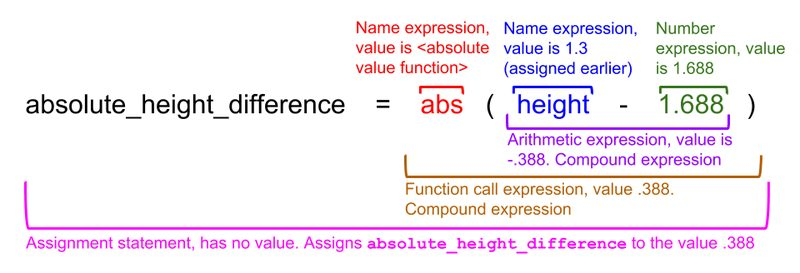">

**Question 1.1.** In the next cell, assign the name `new_year` to the **larger number** among the following two numbers:

* the **absolute value** of $2^{6}-2^{11}-2^{5} - 7$, and
* $5 \times 13 \times 31 + 11$.

Try to use just one line of code. Be sure to check your work by executing the test cell afterward.


In [ ]:
new_year = ...
new_year

In [ ]:
grader.check("q11")

We've asked you to use one line of code in the question above because it only involves mathematical operations. However, more complicated programming questions will require more steps. It isn’t always a good idea to jam these steps into a single line because it can make the code harder to read and harder to debug.

Good programming practice involves splitting up your code into smaller steps and using appropriate names. You'll have plenty of practice in the rest of this course!

## 1.2 Programing Practices in this data science course: Variable Renaming

As a note, it is important not to use variable names that are the same as an existing function name. Take the `max` function for example.

Currently, it works as expected.

In [ ]:
print(max) #  just shows us that this is currently a function
max(5, 6, 7) #  returns 7, as expected

If we use `max` as a variable name, we will no longer be able to use the max function (thus, don’t do this!)

In [ ]:
max = 8 #  you should not do this!
print(max) #  it now prints the number 8, since that was what was stored in it
max(5, 6, 7) #  it no longer works!

Run this cell below to revert the max function back to normal for later use:

In [ ]:
del max

## 2. Importing Code

Most programming involves work that is very similar to work that has been done before.  Since writing code is time-consuming, it's good to rely on others' published code when you can.  Rather than copy-pasting, Python allows us to **import modules**. A module is a file with Python code that has defined variables and functions. By importing a module, we are able to use its code in our own notebook.

Python includes many useful modules that are just an `import` away.  We'll look at the `math` module as a first example. The `math` module is extremely useful in computing mathematical expressions in Python.

Suppose we want to very accurately compute the area of a circle with a radius of 5 meters.  For that, we need the constant $\pi$, which is roughly 3.14.  Conveniently, the `math` module has `pi` defined for us. Run the following cell to import the math module:

In [ ]:
import math
radius = 5
area_of_circle = radius**2 * math.pi
area_of_circle

In the code above, the line `import math` imports the `math` module. We are now able to access any variables or functions defined within `math` by typing `math` followed by a dot, then followed by the name of the variable or function we want.

    <module name>.<name>

**Question 2.1.** The module `math` also provides the name `e` for the base of the natural logarithm, which is roughly 2.71. Compute $e^{\pi}-\pi$, giving it the name `near_twenty`.

*Remember: You can access `pi` from the `math` module as well!*


In [ ]:
near_twenty = ...
near_twenty

In [ ]:
grader.check("q21")

### 2.1. Accessing Functions

In the question above, you accessed variables within the `math` module.

**Modules** also define **functions**.  For example, `math` provides the name `floor` for the floor function.  Having imported `math` already, we can write `math.floor(7.5)` to compute the floor of 7.5.  (Note that the floor function returns the largest integer less than or equal to a given number.)

**Question 2.1.1.** Compute the floor of pi using `floor` and `pi` from the `math` module.  Give the result the name `floor_of_pi`.


In [ ]:
floor_of_pi = ...
floor_of_pi

In [ ]:
grader.check("q211")

For your reference, below are some more examples of functions from the `math` module.

Notice how different functions take in different numbers of arguments. Often, the [documentation](https://docs.python.org/3/library/math.html) of the module will provide information on how many arguments are required for each function.

*Hint: If you press `shift+tab` while next to the function call, the documentation for that function will appear.*

In [ ]:
# Calculating logarithms (the logarithm of 8 in base 2).
# The result is 3 because 2 to the power of 3 is 8.
math.log(8, 2)

In [ ]:
# Calculating square roots.
math.sqrt(5)

There are various ways to import and access code from outside sources. The method we used above — `import <module_name>` — imports the entire module and requires that we use `<module_name>.<variable_or_function_name>` to access its code.

We can also import a specific constant or function instead of the entire module. Notice that you don't have to use the module name beforehand to reference that particular value. However, you do have to be careful about reassigning the names of the constants or functions to other values!

In [ ]:
# Importing just cos and pi from math.
# We don't have to use `math.` in front of cos or pi
from math import cos, pi
print(cos(pi))

# We do have to use it in front of other functions from math, though
math.log(pi)

Or we can import every function and value from the entire module. Now, we do not have to use `math` in front of any functions or values from the `math` module.

In [ ]:
# Lastly, we can import everything from math using the *
# Once again, we don't have to use 'math.' beforehand
from math import *
log(pi)

Don't worry too much about which type of import to use. It's often a coding style choice left up to each programmer. In this course, you'll always import the necessary modules when you run the setup cell (like the first code cell in this lab).

Let's move on to practicing some of the table operations you've learned in lecture!

## 3. Table Operations

The table `farmers_markets.csv` contains data on farmers' markets in the United States  (data associated with [the USDA](https://www.ams.usda.gov/)).  Each row represents one such market.

Run the next cell to load the `farmers_markets` table. There will be no output -- no output is expected as the cell contains an assignment statement. An assignment statement does not produce any output (it does not yield any value).

In [ ]:
# Just run this cell

farmers_markets = Table.read_table('farmers_markets.csv')

Let's examine our table to see what data it contains.

**Question 3.1.** Use the method `show` to display the first 5 rows of `farmers_markets`.

*Note:* The terms "method" and "function" are technically not the same thing, but for the purposes of this course, we will use them interchangeably.

**Hint:** `tbl.show(3)` will show the first 3 rows of the table named `tbl`. Additionally, make sure not to call `.show()` without an argument, as this will crash your kernel!


In [ ]:
...

Notice that some of the values in this table are missing, as denoted by "nan." This means either that the value is not available (e.g. if we don’t know the market’s street address) or not applicable (e.g. if the market doesn’t have a street address). You'll also notice that the table has a large number of columns in it!

### `num_columns`

The table property `num_columns` returns the number of columns in a table. (A "property" is just a method that doesn't need to be called by adding parentheses.)

Example call: `tbl.num_columns` will return the number of columns in a table called `tbl`

**Question 3.2.** Use `num_columns` to find the number of columns in our farmers' markets dataset.

Assign the number of columns to `num_farmers_markets_columns`.


In [ ]:
num_farmers_markets_columns = ...
print("The table has", num_farmers_markets_columns, "columns in it!")

In [ ]:
grader.check("q32")

#### `num_rows`

Similarly, the property `num_rows` tells you how many rows are in a table.

In [ ]:
# Just run this cell

num_farmers_markets_rows = farmers_markets.num_rows
print("The table has", num_farmers_markets_rows, "rows in it!")

#### `select`

Most of the columns are about particular products -- whether the market sells tofu, pet food, etc.  If we're not interested in that information, it just makes the table difficult to read.  This comes up more than you might think, because people who collect and publish data may not know ahead of time what people will want to do with it.

In such situations, we can use the table method `select` to choose only the columns that we want in a particular table. It takes any number of arguments. Each should be the name of a column in the table. It returns a new table with only those columns in it. The columns are in the order *in which they were listed as arguments*.

For example, the value of `farmers_markets.select("MarketName", "State")` is a table with only the name and the state of each farmers' market in `farmers_markets`.

**Question 3.3.** Use `select` to create a table with only the name, city, state, latitude (`y`), and longitude (`x`) of each market.  Call that new table `farmers_markets_locations`.

*Hint:* Make sure to be exact when using column names with `select`; double-check capitalization!


In [ ]:
# Run this cell to see the first row of the farmers_markets table!
farmers_markets.show(1)

In [ ]:
farmers_markets_locations = ...
farmers_markets_locations

In [ ]:
grader.check("q33")

#### `drop`

`drop` serves the same purpose as `select`, but it takes away the columns that you provide rather than the ones that you don't provide. Like `select`, `drop` returns a new table.

**Question 3.4.** Suppose you just didn't want the `FMID` and `updateTime` columns in `farmers_markets`.  Create a table that's a copy of `farmers_markets` but doesn't include those columns.  Call that table `farmers_markets_without_fmid`.


In [ ]:
farmers_markets_without_fmid = ...
farmers_markets_without_fmid

In [ ]:
grader.check("q34")

Now, suppose we want to answer some questions about farmers' markets in the US. For example, which market(s) have the largest longitude (given by the `x` column)?

To answer this, we'll sort `farmers_markets_locations` by longitude.

In [ ]:
farmers_markets_locations.sort('x')

Oops, that didn't answer our question because we sorted from smallest to largest longitude. To look at the largest longitudes, we'll have to sort in reverse order by adding `descending = True` as the second argument.

In [ ]:
farmers_markets_locations.sort('x', descending=True)

(The `descending=True` bit is called an *optional argument*. It has a default value of `False`, so when you explicitly tell the function `descending=True`, then the function will sort in descending order.)

#### `sort`

Some details about sort:

1. The first argument to `sort` is the name of a column to sort by.
2. If the column has text in it, `sort` will sort alphabetically; if the column has numbers, it will sort numerically - both in ascending order by default. For letters, ascending order is from A to Z and descending order is from Z to A.
3. The value of `farmers_markets_locations.sort("x")` is a *copy* of `farmers_markets_locations`; the `farmers_markets_locations` table doesn't get modified. For example, if we called `farmers_markets_locations.sort("x")`, then running `farmers_markets_locations` by itself would still return the unsorted table.
4. Rows always stick together when a table is sorted.  It wouldn't make sense to sort just one column and leave the other columns alone.  For example, in this case, if we sorted just the `x` column, the farmers' markets would all end up with the wrong longitudes.

**Question 3.5.** Create a version of `farmers_markets_locations` that's sorted by **latitude (`y`)**, with the largest latitudes first.  Call it `farmers_markets_locations_by_latitude`.


In [ ]:
farmers_markets_locations_by_latitude = ...
farmers_markets_locations_by_latitude

In [ ]:
grader.check("q35")

Now let's say we want a table of all farmers' markets in California. Sorting won't help us much here because California  is closer to the middle of the dataset.

Instead, we use the table method `where`.

In [ ]:
california_farmers_markets = farmers_markets_locations.where('State', are.equal_to('California'))
california_farmers_markets

Ignore the syntax for the moment.  Instead, try to read that line like this:

> Assign the name **`california_farmers_markets`** to a table whose rows are the rows in the **`farmers_markets_locations`** table **`where`** the **`"State"`** **`are equal to` `"California"`**.

#### `where`

Now let's dive into the details a bit more.  `where` takes 2 arguments:

1. The name of a column.  `where` finds rows where that column's values meet some criterion.
2. A predicate that describes the criterion that the column needs to meet.

The predicate in the example above called the function `are.equal_to` with the value we wanted, 'California'.  We'll see other predicates soon.

`where` returns a table that's a copy of the original table, but **with only the rows that meet the given predicate**.

**Question 3.6.** Use `california_farmers_markets` to create a table called `berkeley_markets` containing farmers' markets in Berkeley, California.

In [ ]:
berkeley_markets = ...
berkeley_markets

In [ ]:
grader.check("q36")

So far we've only been using `where` with the predicate that requires finding the values in a column to be *exactly* equal to a certain value. However, there are many other predicates. We've listed a few common ones below but if you want a more complete list check out the predicates section on the [python reference sheet](https://www.data8.org/fa25/reference/#table-filtering-predicates).

|Predicate|Example|Result|
|-|-|-|
|`are.equal_to`|`are.equal_to(50)`|Find rows with values equal to 50|
|`are.not_equal_to`|`are.not_equal_to(50)`|Find rows with values not equal to 50|
|`are.above`|`are.above(50)`|Find rows with values above (and not equal to) 50|
|`are.above_or_equal_to`|`are.above_or_equal_to(50)`|Find rows with values above 50 or equal to 50|
|`are.below`|`are.below(50)`|Find rows with values below 50|
|`are.between`|`are.between(2, 10)`|Find rows with values above or equal to 2 and below 10|
|`are.between_or_equal_to`|`are.between_or_equal_to(2, 10)`|Find rows with values above or equal to 2 and below or equal to 10|

### 4. Analyzing a dataset

Now that you're familiar with table operations, let’s answer an interesting question about a dataset!

Run the cell below to load the `imdb` table. It contains information about the 250 highest-rated movies on IMDb.

In [ ]:
# Just run this cell

imdb = Table.read_table('imdb.csv')
imdb

Often, we want to perform multiple operations - sorting, filtering, or others - in order to turn a table we have into something more useful. You can do these operations one by one. For example, let's say we have a table called `original_tbl` with columns named "col1" and "col2":

```
first_step = original_tbl.where(“col1”, are.equal_to(12))
second_step = first_step.sort(‘col2’, descending=True)
```

However, since the value of the expression `original_tbl.where(“col1”, are.equal_to(12))` is itself a table, you can just call a table method on it:

```
original_tbl.where(“col1”, are.equal_to(12)).sort(‘col2’, descending=True)
```
You should organize your work in the way that makes the most sense to you, using informative names for any intermediate tables you create.

**Question 4.1.** Create a table of movies released between 2010 and 2015 (**both inclusive**) with ratings above 8. The table should only contain the columns `Title` and `Rating`, **in that order**.

Assign the table to the name `above_eight`.

*Hint:* Think about the steps you need to take, and try to put them in an order that make sense. Feel free to create intermediate tables for each step, but please make sure you assign your final table the name `above_eight`!


In [ ]:
above_eight = ...
above_eight

In [ ]:
grader.check("q41")

**Question 4.2.** Use `num_rows` (and arithmetic) to find the *proportion* of movies in the dataset that were released 1900-1999, and the *proportion* of movies in the dataset that were released in the year 2000 or later.

Assign `proportion_in_20th_century` to the proportion of movies in the dataset that were released 1900-1999, and `proportion_in_21st_century` to the proportion of movies in the dataset that were released in the year 2000 or later.

*Hint:* The *proportion* of movies released in the 1900's is the *number* of movies released in the 1900's, divided by the *total number* of movies.


In [ ]:
num_movies_in_dataset = ...

num_in_20th_century = ...
num_in_21st_century = ...

proportion_in_20th_century = ...
proportion_in_21st_century = ...

print("Proportion in 20th century:", proportion_in_20th_century)
print("Proportion in 21st century:", proportion_in_21st_century)

In [ ]:
grader.check("q42")

### 5. Summary

For your reference, here's a table of all the functions and methods we saw in this lab. We'll learn more methods to add to this table in the coming week!

|Name|Example|Purpose|
|-|-|-|
|`sort`|`tbl.sort("N")`|Create a copy of a table sorted by the values in a column|
|`where`|`tbl.where("N", are.above(2))`|Create a copy of a table with only the rows that match some *predicate*|
|`num_rows`|`tbl.num_rows`|Compute the number of rows in a table|
|`num_columns`|`tbl.num_columns`|Compute the number of columns in a table|
|`select`|`tbl.select("N")`|Create a copy of a table with only some of the columns|
|`drop`|`tbl.drop("N")`|Create a copy of a table without some of the columns|

**Lincoln** the corgi wants to congratulate you on finishing Lab 2!

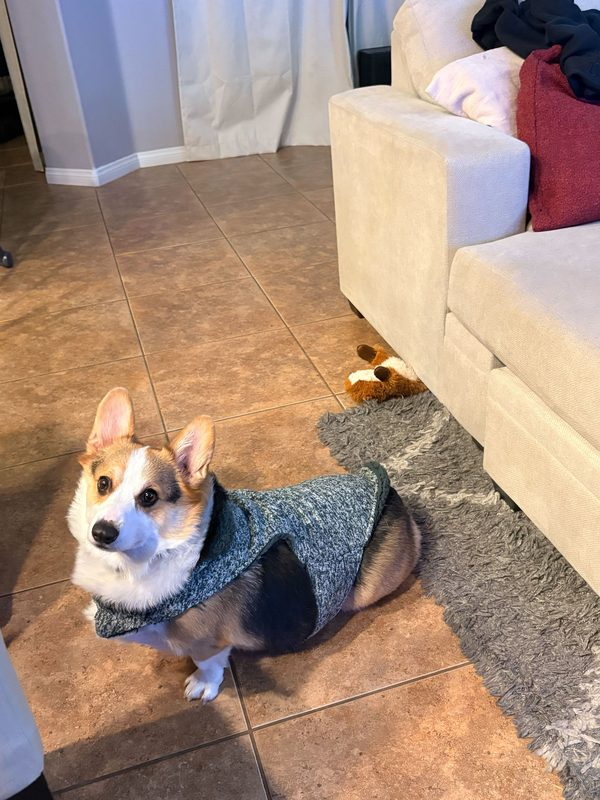


---

You're done with lab!

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_